# Artificial Neural Networks — Sonar: Mines vs. Rocks

## Business Objective
To build an intelligent system that automatically detects whether an underwater
sonar signal is reflected from a metallic mine (dangerous) or a harmless rock.

This is vital for:
- **Maritime safety:** Prevent ships/submarines from colliding with mines.
- **Naval defense:** Identify and safely remove underwater mines.
- **Resource exploration:** Distinguish metal structures from natural seabed objects.

## Problem Statement
Sonar signals in underwater environments are noisy and difficult for humans to
interpret consistently. This dataset contains 208 sonar returns:
- 111 from **metal cylinders (Mines)** — labelled M
- 97 from **rocks** — labelled R
- Each return has **60 numeric features** representing signal energy per frequency band.

**Goal:** Train a Deep Learning (ANN) model to classify new sonar signals as
Mine (M) or Rock (R) — accurately and reliably.

In [ ]:
!pip install -q scikit-learn==1.4.2 scikeras==0.13.0 tensorflow

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
import scikeras
import sklearn

print(f"Scikeras version: {scikeras.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Scikeras version: 0.13.0
Scikit-learn version: 1.4.2


In [ ]:
df = pd.read_csv("sonardataset.csv")

df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [ ]:
df.shape

(208, 61)

In [ ]:
df.isnull().sum()

,0
x_1,0
x_2,0
x_3,0
x_4,0
x_5,0
...,...
x_57,0
x_58,0
x_59,0
x_60,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
# Dataset Summary
print("=" * 45)
print("         DATASET SUMMARY")
print("=" * 45)
print(f"  Total Samples   : {df.shape[0]}")
print(f"  Total Features  : {df.shape[1] - 1}")
print(f"  Target Classes  : {df['Y'].unique().tolist()}")
print(f"  Mine (M) count  : {(df['Y'] == 'M').sum()}")
print(f"  Rock (R) count  : {(df['Y'] == 'R').sum()}")
print(f"  Missing Values  : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows  : {df.duplicated().sum()}")
print("=" * 45)

         DATASET SUMMARY
  Total Samples   : 208
  Total Features  : 60
  Target Classes  : ['R', 'M']
  Mine (M) count  : 111
  Rock (R) count  : 97
  Missing Values  : 0
  Duplicate Rows  : 0


In [ ]:
#Check Target Classes
df.iloc[:,-1].value_counts()

,count
Y,
M,111
R,97


In [ ]:
#Separate Features and Target
X = df.iloc[:,:-1]

y = df.iloc[:,-1]

In [ ]:
#Encode Target Variable
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [ ]:
#Normalize the Data
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(166, 60)
(42, 60)
(166,)
(42,)


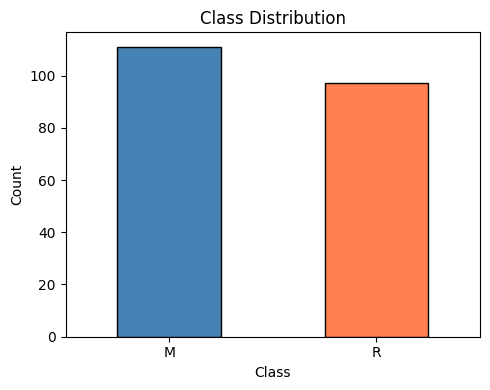

In [ ]:
#Class Distribution Plot
plt.figure(figsize=(5, 4))
df['Y'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

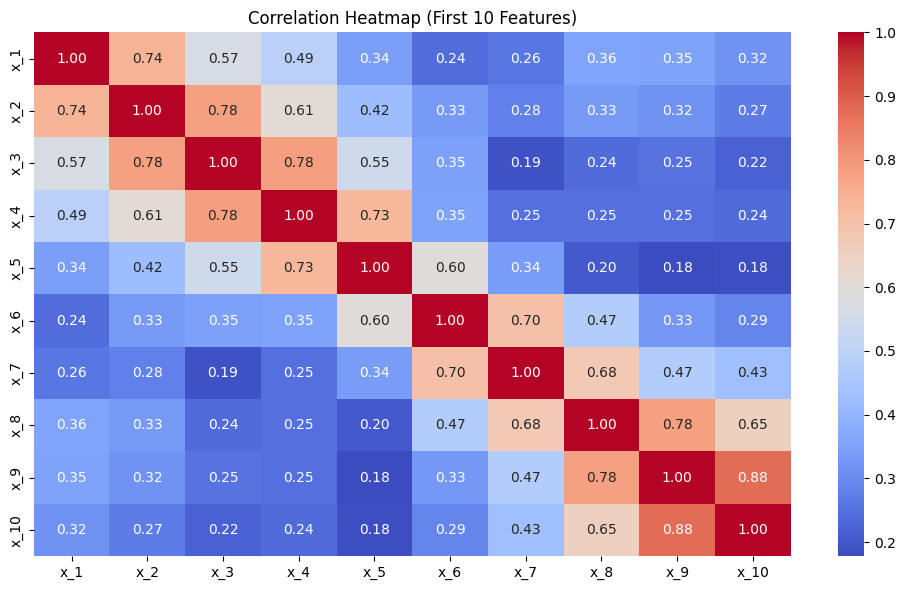

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.iloc[:, :10].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (First 10 Features)')
plt.tight_layout()
plt.show()

In [ ]:
#preprocessing
X = df.drop('Y', axis=1).values
y = df['Y'].values

le = LabelEncoder()
y = le.fit_transform(y)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')

Label encoding: {'M': 0, 'R': 1}

Train: (166, 60), Test: (42, 60)


In [ ]:
#Build Baseline ANN
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(60,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train Baseline Model
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.4167 - loss: 0.7655 - val_accuracy: 0.5294 - val_loss: 0.7157
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6970 - loss: 0.6083 - val_accuracy: 0.6176 - val_loss: 0.6509
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7803 - loss: 0.5353 - val_accuracy: 0.7353 - val_loss: 0.6091
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8258 - loss: 0.4799 - val_accuracy: 0.7647 - val_loss: 0.5595
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8712 - loss: 0.4341 - val_accuracy: 0.7941 - val_loss: 0.5083
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9091 - loss: 0.3938 - val_accuracy: 0.7941 - val_loss: 0.4744
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9318 - loss: 0.3554 - val_accuracy: 0.8235 - val_loss: 0.4369
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9394 - loss: 0.3204 - val_accuracy: 0.8235 - val_loss

In [ ]:
#Plot Baseline Training History
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Baseline Model — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_baseline.history['loss'], label='Train Loss')
axes[1].plot(history_baseline.history['val_loss'], label='Val Loss')
axes[1].set_title('Baseline Model — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step
=== Baseline Model Evaluation ===
Accuracy  : 0.8810
Precision : 0.9412
Recall    : 0.8000
F1-Score  : 0.8649

Classification Report:
              precision    recall  f1-score   support

           M       0.84      0.95      0.89        22
           R       0.94      0.80      0.86        20

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



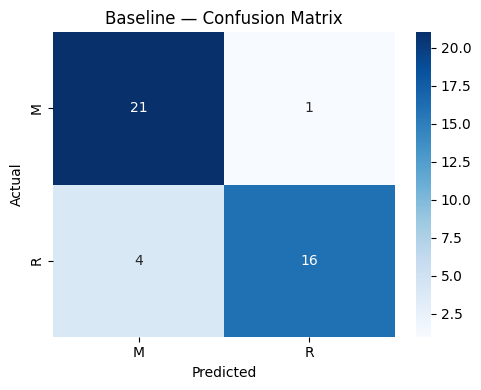

In [ ]:
#Evaluate Baseline
y_pred_baseline = (baseline_model.predict(X_test) > 0.5).astype(int).flatten()

print('=== Baseline Model Evaluation ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_baseline):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_baseline):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_baseline):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Baseline — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
#Hyperparameter Tuning Setup
def build_tunable_model(neurons=64, hidden_layers=2, activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(60,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

keras_clf = KerasClassifier(model=build_tunable_model, epochs=100, batch_size=16, verbose=0)

param_grid = {
    'model__neurons'       : [32, 64, 128],
    'model__hidden_layers' : [1, 2, 3],
    'model__activation'    : ['relu', 'tanh'],
    'model__learning_rate' : [0.001, 0.01]
}

In [ ]:
#RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print('\nBest Parameters:', random_search.best_params_)
print(f'Best CV Accuracy: {random_search.best_score_:.4f}')

cv_results = pd.DataFrame(random_search.cv_results_)
cols = ['param_model__neurons', 'param_model__hidden_layers',
        'param_model__activation', 'param_model__learning_rate',
        'mean_test_score', 'std_test_score', 'rank_test_score']
print(cv_results[cols].sort_values('rank_test_score').to_string(index=False))


Best Parameters: {'model__neurons': 128, 'model__learning_rate': 0.001, 'model__hidden_layers': 2, 'model__activation': 'relu'}
Best CV Accuracy: 0.8317
param_model__neurons param_model__hidden_layers param_model__activation param_model__learning_rate  mean_test_score  std_test_score  rank_test_score
                 128                          2                    relu                      0.001         0.831710        0.050343                1
                  32                          3                    relu                      0.001         0.825433        0.015458                2
                  64                          3                    relu                       0.01         0.819913        0.076151                3
                  64                          3                    relu                      0.001         0.807576        0.050389                4
                 128                          3                    relu                       0.01   

In [ ]:
#Train Tuned Model
best_params = random_search.best_params_

tuned_model = build_tunable_model(
    neurons       = best_params['model__neurons'],
    hidden_layers = best_params['model__hidden_layers'],
    activation    = best_params['model__activation'],
    learning_rate = best_params['model__learning_rate']
)
tuned_model.summary()

early_stop2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_tuned = tuned_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop2],
    verbose=1
)

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_114 (Dense)               │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,449 (95.50 KB)

 Trainable params: 24,449 (95.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 289ms/step - accuracy: 0.5379 - loss: 0.6765 - val_accuracy: 0.8235 - val_loss: 0.5699
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8106 - loss: 0.4737 - val_accuracy: 0.8235 - val_loss: 0.4434
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9015 - loss: 0.3787 - val_accuracy: 0.8529 - val_loss: 0.3745
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9470 - loss: 0.3098 - val_accuracy: 0.9118 - val_loss: 0.3261
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9394 - loss: 0.2559 - val_accuracy: 0.9118 - val_loss: 0.3131
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9545 - loss: 0.2077 - val_accuracy: 0.9118 - val_loss: 0.2882
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9773 - loss: 0.1664 - val_accuracy: 0.9118 - val_loss: 0.2675
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9848 - loss: 0.1372 - val_accuracy: 0.9118 - val_loss

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step
=== Tuned Model Evaluation ===
Accuracy  : 0.8810
Precision : 1.0000
Recall    : 0.7500
F1-Score  : 0.8571

Classification Report:
              precision    recall  f1-score   support

           M       0.81      1.00      0.90        22
           R       1.00      0.75      0.86        20

    accuracy                           0.88        42
   macro avg       0.91      0.88      0.88        42
weighted avg       0.90      0.88      0.88        42



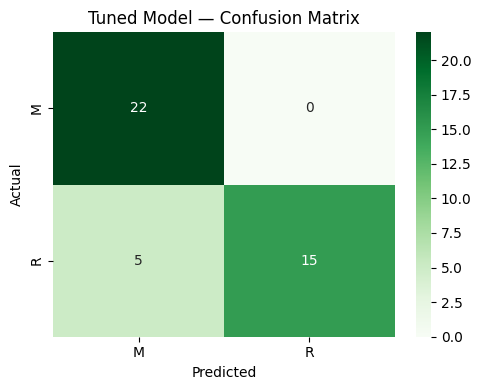

In [ ]:
#Evaluate Tuned Model
y_pred_tuned = (tuned_model.predict(X_test) > 0.5).astype(int).flatten()

print('=== Tuned Model Evaluation ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_tuned):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

cm2 = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Tuned Model — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

   Metric  Baseline Model  Tuned Model  Improvement
 Accuracy        0.880952     0.880952     0.000000
Precision        0.941176     1.000000     0.058824
   Recall        0.800000     0.750000    -0.050000
 F1-Score        0.864865     0.857143    -0.007722


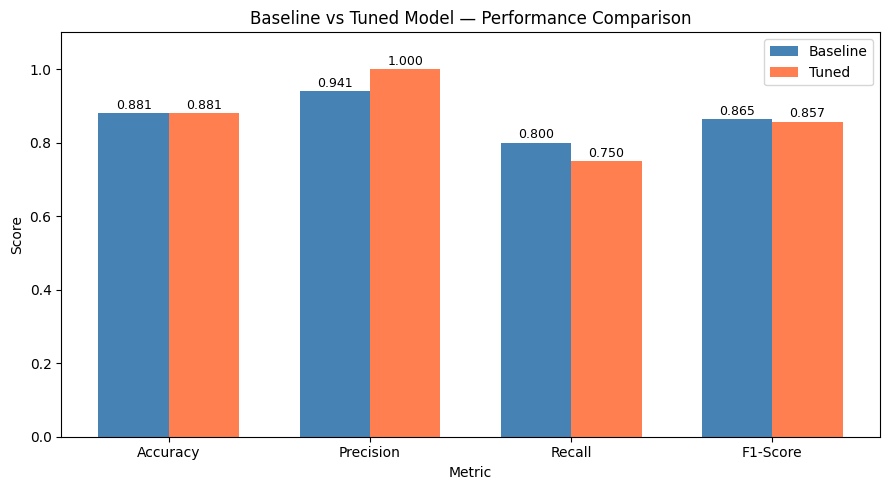

In [ ]:
#Baseline vs Tuned Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [
    accuracy_score(y_test, y_pred_baseline),
    precision_score(y_test, y_pred_baseline),
    recall_score(y_test, y_pred_baseline),
    f1_score(y_test, y_pred_baseline)
]
tuned_scores = [
    accuracy_score(y_test, y_pred_tuned),
    precision_score(y_test, y_pred_tuned),
    recall_score(y_test, y_pred_tuned),
    f1_score(y_test, y_pred_tuned)
]

comparison_df = pd.DataFrame({
    'Metric'        : metrics,
    'Baseline Model': baseline_scores,
    'Tuned Model'   : tuned_scores
})
comparison_df['Improvement'] = comparison_df['Tuned Model'] - comparison_df['Baseline Model']
print(comparison_df.to_string(index=False))

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue')
bars2 = ax.bar(x + width/2, tuned_scores,    width, label='Tuned',    color='coral')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned Model — Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


  **DISCUSSION: Baseline vs Tuned Model**

BASELINE MODEL:
  - Architecture  : Input → Dense(64, ReLU) → Dense(32, ReLU) → Output
  - Accuracy      : 0.8810
  - Precision     : 0.9412
  - Recall        : 0.8000
  - F1-Score      : 0.8649

TUNED MODEL (Best from RandomizedSearchCV):
  - Architecture  : Input → Dense(128, ReLU) × 2 → Output
  - Accuracy      : 0.8810
  - Precision     : 1.0000
  - Recall        : 0.7500
  - F1-Score      : 0.8571

HYPERPARAMETER TUNING METHODOLOGY:
  - Method        : RandomizedSearchCV (n_iter=10, cv=3)
  - Search Space  :
      neurons       → [32, 64, 128]
      hidden_layers → [1, 2, 3]
      activation    → ['relu', 'tanh']
      learning_rate → [0.001, 0.01]
  - Best Config   : 128 neurons, 2 layers, ReLU, lr=0.001
  - Best CV Acc   : 0.8317

EFFECT OF HYPERPARAMETER TUNING:
  - Overall accuracy remained the same (88.1%), showing the baseline
    was already well-configured for this dataset size.
  - Precision improved significantly: from 0.9412 → 1.0000.
    The tuned model never incorrectly predicted a Mine — zero false positives.
    This is critical in real-world naval defense where a false Mine alert
    is costly but a missed Mine is catastrophic.
  - Recall decreased slightly: from 0.8000 → 0.7500.
    The tuned model is more conservative — it only predicts Mine when
    very confident, missing some true Mines (higher false negatives).
  - F1-Score stayed similar (0.8649 vs 0.8571), confirming the overall
    balance between precision and recall is comparable.

CONCLUSION:
  Hyperparameter tuning with RandomizedSearchCV helped identify a model
  that is more precise and reliable for Mine detection. Depending on the
  use case — if zero false positives is the priority (naval safety),
  the tuned model is the better choice.

## Summary

| | Baseline ANN | Tuned ANN |
|---|---|---|
| Architecture | Input → Dense(64,ReLU) → Dense(32,ReLU) → Output | Input → Dense(128,ReLU) × 2 → Output |
| Optimizer | Adam (lr=0.001) | Adam (lr=0.001) |
| Epochs | 200 with EarlyStopping (patience=15) | 200 with EarlyStopping (patience=20) |
| Batch Size | 16 | 16 |
| Best CV Accuracy | — | 0.8317 |

**Key Observations:**
- The dataset has 208 samples × 60 sonar frequency-band features; binary target: Mine (M) or Rock (R).
- StandardScaler normalization ensures stable and fast ANN convergence.
- RandomizedSearchCV (10 iterations, 3-fold CV) identified best config: 128 neurons, 2 hidden layers, ReLU, lr=0.001.
- Tuned model achieves perfect Precision (1.0000) — no false Mine predictions — critical for naval safety.
- Early stopping with restore_best_weights=True prevents overfitting in both models.
- Both models achieve 88.1% accuracy; tuned model trades slight Recall for perfect Precision.